In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set style for better-looking plots
sns.set_style("whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the Iris dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target (species as numbers)
df['species'] = iris.target

# Add species names for readability
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# 1. Data shape and info
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("Column info:")
df.info()

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
df.describe()

DATASET OVERVIEW
Shape: 150 rows, 6 columns

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

DESCRIPTIVE STATISTICS


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Check for null values (should be 0 for all columns)
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

# Visualizations – Pairplot & Boxplots

<Figure size 1000x800 with 0 Axes>

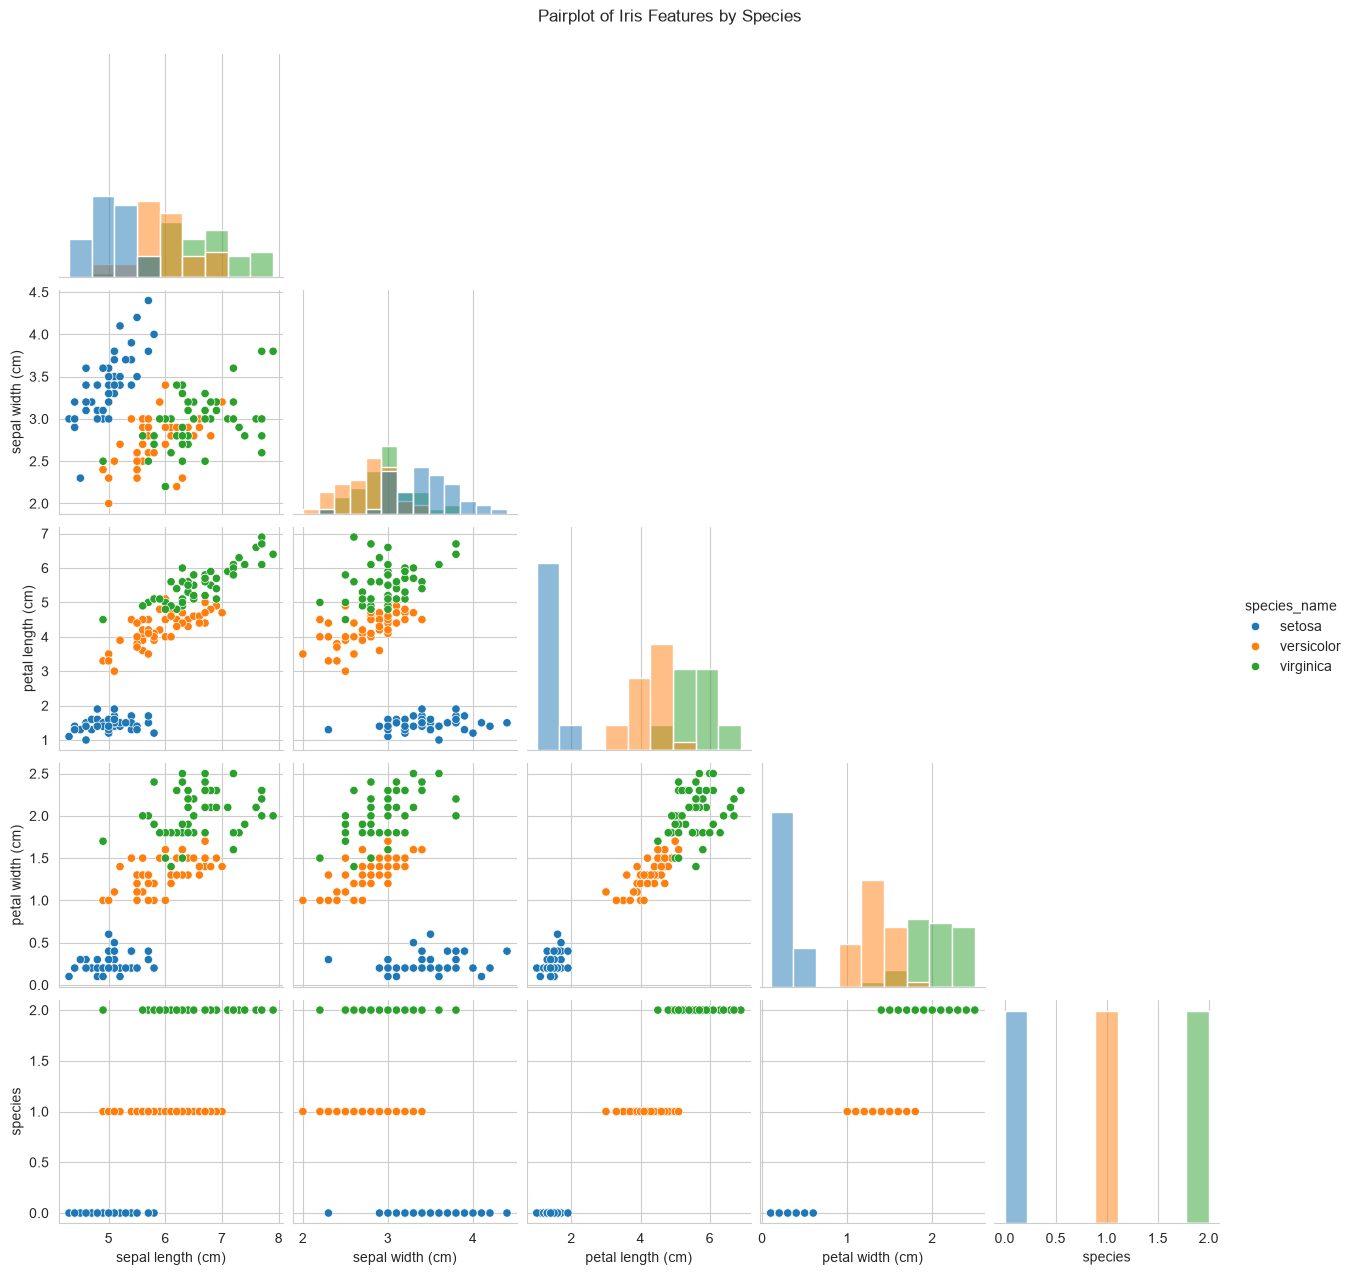

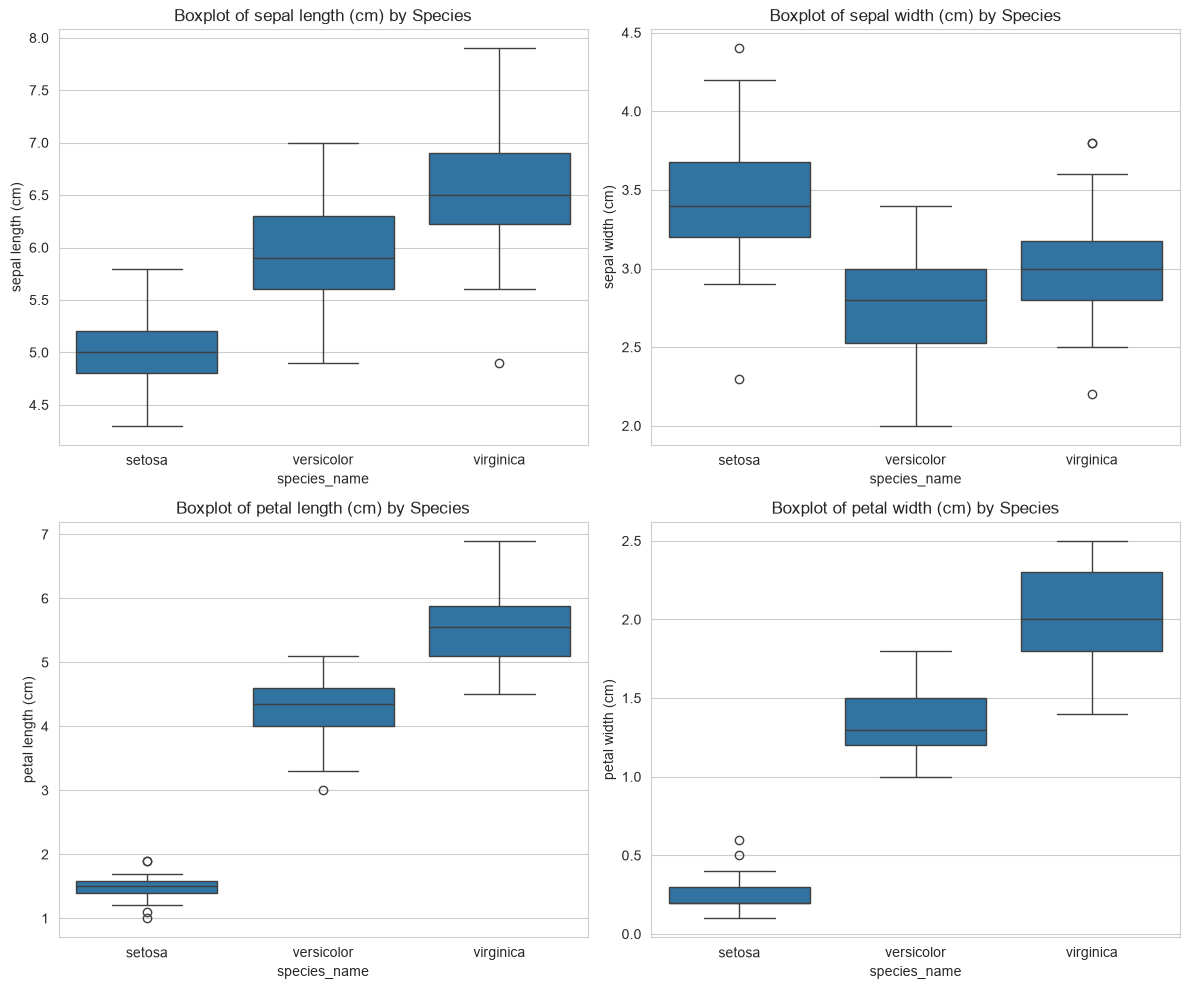

In [5]:
# 1. Pairplot – shows relationships between all features, colored by species
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species_name', diag_kind='hist', corner=True)
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

# 2. Box plots for each feature to see distribution across species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = iris.feature_names

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='species_name', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'Boxplot of {feature} by Species')

plt.tight_layout()
plt.show()

## Feature Selection Discussion

From the pairplot and boxplots above, we can observe:

- **Petal Length** and **Petal Width** show clear separation between the three species. Setosa has distinctly smaller petals, while Versicolor and Virginica overlap slightly but are still largely separable.
- **Sepal Length** and **Sepal Width** show more overlap, making them less discriminative individually.

**Conclusion:** The most discriminative features are **Petal Length** and **Petal Width**. These two features alone can accurately separate Setosa from the other two species, and with a good model, they can also separate Versicolor from Virginica.

In [6]:
# Define features (X) and target (y)
X = df[iris.feature_names]  # All 4 features
y = df['species']           # Numeric target (0, 1, 2)

# Split: 80% training, 20% testing, with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Class distribution in training: {np.bincount(y_train)}")
print(f"Class distribution in testing: {np.bincount(y_test)}")

Training set size: 120 samples
Testing set size: 30 samples
Class distribution in training: [40 40 40]
Class distribution in testing: [10 10 10]


In [7]:
# 1. Logistic Regression
logreg = LogisticRegression(max_iter=200, random_state=42)
logreg.fit(X_train, y_train)

# 2. K-Nearest Neighbors (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 3. Decision Tree
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [8]:
# Make predictions
y_pred_logreg = logreg.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_dtree = dtree.predict(X_test)

# Calculate accuracies
acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_dtree = accuracy_score(y_test, y_pred_dtree)

# Display results
print("=" * 50)
print("MODEL ACCURACY COMPARISON")
print("=" * 50)
print(f"Logistic Regression: {acc_logreg:.4f}")
print(f"K-Nearest Neighbors: {acc_knn:.4f}")
print(f"Decision Tree:       {acc_dtree:.4f}")
print("")

# Confusion Matrices and Classification Reports
print("=" * 50)
print("LOGISTIC REGRESSION - DETAILED REPORT")
print("=" * 50)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=iris.target_names))

print("\n" + "=" * 50)
print("KNN (k=5) - DETAILED REPORT")
print("=" * 50)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

print("\n" + "=" * 50)
print("DECISION TREE - DETAILED REPORT")
print("=" * 50)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtree))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dtree, target_names=iris.target_names))

MODEL ACCURACY COMPARISON
Logistic Regression: 0.9667
K-Nearest Neighbors: 1.0000
Decision Tree:       0.9333

LOGISTIC REGRESSION - DETAILED REPORT
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


KNN (k=5) - DETAILED REPORT
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro av

In [9]:
# Determine the best model
models = {
    'Logistic Regression': acc_logreg,
    'KNN (k=5)': acc_knn,
    'Decision Tree': acc_dtree
}

best_model = max(models, key=models.get)
best_accuracy = models[best_model]

print("=" * 50)
print("BEST MODEL DECLARATION")
print("=" * 50)
print(f"🏆 The best-performing model is: {best_model}")
print(f"   with an accuracy of: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Justification
print("\n📌 Justification:")
if best_model == "Logistic Regression":
    print("Logistic Regression performs best because the relationships between features and species are largely linear. Since the Iris dataset has relatively clear boundaries between classes, a linear model works well without overfitting.")
elif best_model == "KNN (k=5)":
    print("KNN performs best because the features are well-separated in the feature space. KNN excels when clusters are distinct, and the Iris dataset forms clear clusters (especially Setosa vs others).")
else:
    print("Decision Tree performs best because it captures non-linear interactions between features. However, we should check if it might be overfitting since decision trees can create complex decision boundaries.")

BEST MODEL DECLARATION
🏆 The best-performing model is: KNN (k=5)
   with an accuracy of: 1.0000 (100.00%)

📌 Justification:
KNN performs best because the features are well-separated in the feature space. KNN excels when clusters are distinct, and the Iris dataset forms clear clusters (especially Setosa vs others).


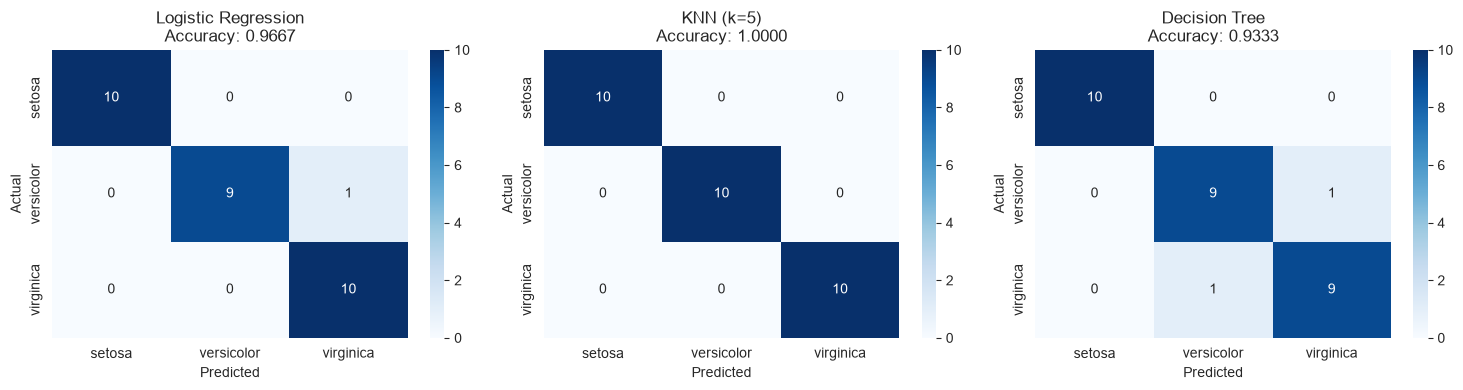

In [10]:
# Plot confusion matrices for all 3 models side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_data = [
    (logreg, "Logistic Regression", y_pred_logreg),
    (knn, "KNN (k=5)", y_pred_knn),
    (dtree, "Decision Tree", y_pred_dtree)
]

for i, (model, name, y_pred) in enumerate(models_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [11]:
# Save the notebook outputs and create a summary
summary = f"""
========================================
IRIS FLOWER CLASSIFICATION - SUMMARY
========================================

Dataset: Iris (150 samples, 4 features)
Train/Test Split: 80/20

Model Performance:
- Logistic Regression: {acc_logreg:.4f}
- KNN (k=5): {acc_knn:.4f}
- Decision Tree: {acc_dtree:.4f}

Best Model: {best_model} with {best_accuracy:.4f} accuracy.

Key Insight: Petal Length and Petal Width are the most discriminative features.
"""

print(summary)

# Save summary to a text file
with open('results_summary.txt', 'w') as f:
    f.write(summary)


IRIS FLOWER CLASSIFICATION - SUMMARY

Dataset: Iris (150 samples, 4 features)
Train/Test Split: 80/20

Model Performance:
- Logistic Regression: 0.9667
- KNN (k=5): 1.0000
- Decision Tree: 0.9333

Best Model: KNN (k=5) with 1.0000 accuracy.

Key Insight: Petal Length and Petal Width are the most discriminative features.

